In [1]:
import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm

sys.path.append('../src')
from utils import (
    CFG, ShopeeDataset, get_transforms,
    ShopeeImageModel, ArcFaceLoss,
    get_text_embeddings, get_neighbors, mean_f1, log_result
)

# ── LIGHTWEIGHT OVERRIDES ──────────────────────
CFG.IMG_MODEL   = 'efficientnet_b0'   # was b5 — 6x fewer params
CFG.IMG_SIZE    = 224                 # was 512 — 5x fewer pixels
CFG.EMBED_DIM   = 128                 # was 512 — smaller embedding
CFG.BATCH_SIZE  = 8                   # was 16 — half the memory
CFG.EPOCHS      = 2                   # was 5 — just enough to converge
CFG.ARC_S       = 30.0
CFG.ARC_M       = 0.5
# ───────────────────────────────────────────────

print(f"Device     : {CFG.DEVICE}")
print(f"Image model: {CFG.IMG_MODEL}")
print(f"Image size : {CFG.IMG_SIZE}")
print(f"Batch size : {CFG.BATCH_SIZE}")
print(f"Epochs     : {CFG.EPOCHS}")

Device: cpu
Data dir exists: True
✅ utils.py loaded successfully
Device     : cpu
Image model: efficientnet_b0
Image size : 224
Batch size : 8
Epochs     : 2


In [2]:
import torch
print(f"CUDA available : {torch.cuda.is_available()}")
print(f"CPU cores      : {torch.get_num_threads()}")

import psutil
ram = psutil.virtual_memory()
print(f"Total RAM      : {ram.total / 1e9:.1f} GB")
print(f"Available RAM  : {ram.available / 1e9:.1f} GB")

CUDA available : False
CPU cores      : 4
Total RAM      : 16.9 GB
Available RAM  : 3.4 GB


In [3]:
# Load Data

df = pd.read_csv(CFG.TRAIN_CSV)

# ── USE ONLY 20% OF DATA ──────────────────────
# Filter to groups that appear at least twice
# (singletons are useless for metric learning)
group_sizes   = df.groupby('label_group').size()
valid_groups  = group_sizes[group_sizes >= 2].index
df            = df[df['label_group'].isin(valid_groups)].reset_index(drop=True)

# Sample 20% of groups (not rows — keep groups intact)
unique_groups  = df['label_group'].unique()
sampled_groups = pd.Series(unique_groups).sample(
    frac=0.20, random_state=42
).values
df = df[df['label_group'].isin(sampled_groups)].reset_index(drop=True)
# ──────────────────────────────────────────────

print(f"Sampled dataset size : {len(df):,} rows")
print(f"Unique groups        : {df['label_group'].nunique():,}")

# Train/val split
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train size : {len(train_df):,}")
print(f"Val size   : {len(val_df):,}")

Sampled dataset size : 7,035 rows
Unique groups        : 2,203
Train size : 5,628
Val size   : 1,407


In [4]:
# Build DataLoaders

train_dataset = ShopeeDataset(
    train_df,
    CFG.TRAIN_IMG_DIR,
    transform=get_transforms(CFG.IMG_SIZE, mode='train')
)

val_dataset = ShopeeDataset(
    val_df,
    CFG.TRAIN_IMG_DIR,
    transform=get_transforms(CFG.IMG_SIZE, mode='val')
)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=0,        # ← 0 = no multiprocessing, safer on Windows/Mac
    pin_memory=False      # ← False when no GPU
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Train batches : 704
Val batches   : 176


In [5]:
# Initialize Model & Loss

# Image model — EfficientNet-B5 (baseline)
model = ShopeeImageModel(
    model_name=CFG.IMG_MODEL,
    embed_dim=CFG.EMBED_DIM,
    pretrained=True
).to(CFG.DEVICE)

# ArcFace loss — margin m=0.5 (baseline)
criterion = ArcFaceLoss(
    in_features=CFG.EMBED_DIM,
    num_classes=train_dataset.num_classes,
    s=CFG.ARC_S,
    m=CFG.ARC_M
).to(CFG.DEVICE)

# Optimizer — train both model and ArcFace weights together
optimizer = torch.optim.Adam([
    {'params': model.parameters()},
    {'params': criterion.parameters()}
], lr=CFG.LR)

# Learning rate scheduler — reduces LR when loss plateaus
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG.EPOCHS
)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print("Model and loss have been initialized")


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Model parameters: 4,171,772
Model and loss have been initialized


c:\D\masters\shopee-multimodal-matching\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\henry\.cache\huggingface\hub\models--timm--efficientnet_b0.ra_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [6]:
# Training Loop

def train_one_epoch(model, criterion, loader, optimizer, device):
    model.train()
    criterion.train()
    total_loss = 0

    for batch_idx, (images, labels) in enumerate(tqdm(loader, desc='Training')):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        embeddings = model(images)
        loss = criterion(embeddings, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Print memory usage every 20 batches
        if batch_idx % 20 == 0:
            import psutil
            ram_used = psutil.virtual_memory().percent
            print(f"  Batch {batch_idx}/{len(loader)} — Loss: {loss.item():.4f} — RAM: {ram_used}%")

            # Emergency brake — stop if RAM > 90%
            if ram_used > 90:
                print("[!] RAM > 90% — stopping early to prevent crash!")
                break

    return total_loss / len(loader)


# Training
history = {'train_loss': []}

for epoch in range(CFG.EPOCHS):
    train_loss = train_one_epoch(
        model, criterion, train_loader, optimizer, CFG.DEVICE
    )
    scheduler.step()
    history['train_loss'].append(train_loss)
    print(f"Epoch {epoch+1}/{CFG.EPOCHS} — Loss: {train_loss:.4f}")

print("\n Training complete")

Training:   0%|          | 1/704 [00:02<27:44,  2.37s/it]

  Batch 0/704 — Loss: 25.1950 — RAM: 83.5%


Training:   3%|▎         | 21/704 [00:38<20:18,  1.78s/it]

  Batch 20/704 — Loss: 24.6495 — RAM: 82.8%


Training:   6%|▌         | 41/704 [01:14<20:22,  1.84s/it]

...

  Batch 680/704 — Loss: 19.3747 — RAM: 74.4%


Training: 100%|█████████▉| 701/704 [19:19<00:04,  1.61s/it]

  Batch 700/704 — Loss: 20.5473 — RAM: 73.8%


Training: 100%|██████████| 704/704 [19:24<00:00,  1.65s/it]

Epoch 2/2 — Loss: 18.9924

 Training complete


In [7]:
# Extract Embeddings from Validation Set

def extract_embeddings(model, loader, device):
    """
    Run the trained model in inference mode.
    Returns a (N, embed_dim) numpy array of L2-normalized embeddings.
    """
    model.eval()
    all_embeddings = []

    with torch.no_grad():
        for images, _ in tqdm(loader, desc='Extracting embeddings'):
            images     = images.to(device)
            embeddings = model(images)
            all_embeddings.append(embeddings.cpu().numpy())

    return np.vstack(all_embeddings)

image_embeddings = extract_embeddings(model, val_loader, CFG.DEVICE)
print(f"Image embeddings shape: {image_embeddings.shape}")


Extracting embeddings: 100%|██████████| 176/176 [01:22<00:00,  2.15it/s]

Image embeddings shape: (1407, 128)


In [8]:
# Add Text Embeddings & Combine

# Get text embeddings for validation titles
print("Encoding text titles with XLM-R...")
text_embeddings = get_text_embeddings(
    val_df['title'],
    model_name=CFG.TEXT_MODEL
)
print(f"Text embeddings shape: {text_embeddings.shape}")

# Combine image + text embeddings by concatenation then re-normalize
combined = np.concatenate([image_embeddings, text_embeddings], axis=1)
norms = np.linalg.norm(combined, axis=1, keepdims=True)
combined = combined / (norms + 1e-6)

print(f"Combined embeddings shape: {combined.shape}")

Encoding text titles with XLM-R...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

c:\D\masters\shopee-multimodal-matching\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\henry\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Text embeddings shape: (1407, 384)
Combined embeddings shape: (1407, 512)


In [9]:
# Evaluate: Find Neighbors & Compute F1

# threshold=0.5 is the standard starting point — tune if needed
predictions = get_neighbors(combined, threshold=0.5)

# Compute mean F1 score
f1 = mean_f1(val_df, predictions)
print(f"\n{'='*40}")
print(f"  BASELINE MEAN F1 SCORE: {f1:.4f}")
print(f"{'='*40}")

# Save trained model weights for reuse in ablation experiments
os.makedirs('../results', exist_ok=True)
torch.save(model.state_dict(), '../results/baseline_model.pth')
print("Model saved to results/baseline_model.pth")

# Log to your ablation CSV — this is your control row
log_result(
    experiment = 'Baseline',
    img_model  = CFG.IMG_MODEL,       # efficientnet_b5
    text_model = CFG.TEXT_MODEL,      # paraphrase-xlm-r-multilingual-v1
    arcface_m  = CFG.ARC_M,           # 0.5
    f1_score   = f1
)


  BASELINE MEAN F1 SCORE: 0.7233
Model saved to results/baseline_model.pth
✅ Logged: Baseline → F1 = 0.7233
experiment       img_model                            text_model  arcface_m  f1_score
  Baseline efficientnet_b0 paraphrase-multilingual-MiniLM-L12-v2        0.5    0.7233


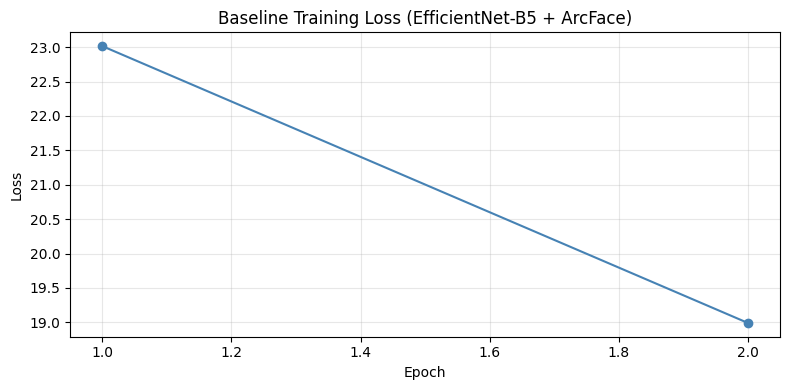

Final baseline F1: 0.7233
Screenshot this — it goes in your paper's Experiment section!


In [10]:
# Plot Training Loss

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, CFG.EPOCHS+1), history['train_loss'], marker='o', color='steelblue')
plt.title('Baseline Training Loss (EfficientNet-B5 + ArcFace)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/baseline_loss_curve.png', dpi=150)
plt.show()

print(f"Final baseline F1: {f1:.4f}")
print("Screenshot this — it goes in your paper's Experiment section!")